## Настройка окружения

#### Подключение Google Диска

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Установка зависимостей

In [ ]:
%%capture --no-stderr
%pip install langchain_community langgraph_sdk langchain_openai langgraph langgraph-checkpoint-sqlite aiosqlite trustcall langchain_core tavily-python langsmith ftfy openai httpx==0.27.2

#### Импорты

In [ ]:
import os
import time
import re
import requests
import json
import yaml
import datetime
import operator
import urllib.parse
from urllib.parse import urlparse
from ftfy import fix_text
import uuid
import builtins
from io import BytesIO

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables.config import RunnableConfig
from langgraph.constants import Send
from langchain_core.utils.function_calling import convert_to_openai_tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langgraph.types import interrupt, Command

from IPython.display import display
from IPython.display import Image as IPythonImage

from langchain_community.document_loaders import WikipediaLoader
from langchain_community.tools import TavilySearchResults

from jinja2 import Template
from pydantic import BaseModel, Field
from typing import Annotated, Any, Optional, List, Literal, Union
from typing_extensions import TypedDict

import openai
from openai import OpenAI, Client

#### Переменные окружения

In [ ]:
from google.colab import userdata

os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')
os.environ['NEWS_FIREWORKS_API_KEY'] = userdata.get('NEWS_FIREWORKS_API_KEY')
os.environ['PERPLEXITY_API_KEY'] = userdata.get('STAS_PERPLEXITY_API_KEY')
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

FIREWORKS_API_KEY = os.getenv("NEWS_FIREWORKS_API_KEY")

os.environ['LANGSMITH_TRACING'] = "true"
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['API_BASE_URL'] = "https://api.fireworks.ai/inference/v1"

#### Конфиги

In [ ]:
main_dir = "./drive/MyDrive/lecture_langgraph_advanced"
base_config_dir = os.path.join(main_dir, "config")

os.environ['PROMPTS_CONFIG_PATH'] = os.path.join(base_config_dir, 'prompts.yaml')
os.environ['GRAPH_CONFIG_PATH'] = os.path.join(base_config_dir, 'graph.yaml')

### Prompts

In [ ]:
GENERATING_CONTENT_SYSTEM_PROMPT_TEMPLATE = Template(
"""
KEYWORD: cryptography, mathematics, explanation

<role>
Your are a university-level cryptography professor, whose mission is to produce a **thorough, comprehensive, and absolutely exhaustive educational material** on the given exam question. The student must gain a 100% understanding of the topic by studying your material. If the student presents your content as their answer, the examiner should have no follow-up questions and should immediately award the highest grade ("excellent").
</role>

<exam_question>
{{ exam_question }}
</exam_question>

<requirements>
1. **Comprehensiveness**: Cover the topic from all necessary angles — definitions, context, theory, practical relevance, historical notes if useful, and connections to real cryptographic algorithms.
2. **Clarity**: Use clear, precise, unambiguous language. Avoid vague formulations and strive for crystal-clear logic in every step.
3. **Mathematics**: If mathematical formulas, concepts, or derivations are required for a complete understanding, present each formula with a **detailed, step-by-step derivation**.
    - Explain every symbol and each step of the logic.
    - After the mathematical exposition, show **how this formula or principle is used in practical cryptographic algorithms**.
    - Illuminate the connection between mathematical theory and real-world cryptography.
    - For inline mathematical formulas, use single dollar signs:
        Example: The speed of light: `$c = 3 \times 10^8\ m/s$`
    - For display (block) mathematical formulas, use double dollar signs:
        Example:
        $$
        \vec{F} = m \vec{a} = m \frac{d\vec{v}}{dt}
        $$
4. **Examples and Intuition**: Where possible, provide intuitive analogies, illustrative examples, or diagrams (in text format) to make abstract concepts accessible.
5. **No Gaps**: Ensure there are no "white spots" in your answer. Anticipate and address all potential follow-up questions.
6. **Self-sufficiency**: The answer should be self-contained — a student unfamiliar with the topic must be able to master it using only your material.
7. **Response language**: Always response in the Russian Language.
8. **Target audience**: The target audience is advanced students (graduate/master’s/PhD level). Therefore, do **not** explain or dwell on basic/foundational cryptographic concepts. Focus on advanced aspects, recent research, deep mathematical structure, and practical subtleties. Assume the reader is already well-versed in core cryptographic notions and terminology.
</requirements>
"""
)

In [ ]:
GEN_QUESTION_SYSTEM_PROMPT_TEMPLATE = Template(
"""
KEYWORD: cryptography, exam, teaching, knowledge gaps, question generation

<role>
You are a university-level cryptography instructor. Your main goal is to assess the depth of the student's preparation for a given exam question by analyzing their provided study material and to expand their understanding beyond the covered content.
</role>

<task>
Given:
- <exam_question> {{ exam_question }} </exam_question>
- <study_material> {{ study_material }} </study_material>

You must:
1. Carefully analyze the content between <study_material>...</study_material> to identify the main topics, subtopics, and level of detail.
2. Compare this material with the requirements and scope implied by <exam_question>...</exam_question>.
3. Identify 5 questions from the domain of <exam_question> that are either:
   - Entirely absent in <study_material>
   - Mentioned only superficially or with insufficient explanation in <study_material>
4. The questions must be relevant, non-trivial, and require a deeper or broader understanding than what is present in <study_material>.
</task>

Present your output in the following JSON schema:
{{ json_schema }}

<important>
- ONLY use content between <study_material>...</study_material> for coverage analysis.
- Your additional questions MUST relate directly to the domain specified by <exam_question>.
- Do NOT provide any answers to the generated questions.
- For references, always point to the relevant content between <study_material> tags.
- The goal is to challenge the student to fill their knowledge gaps.
- Always response in the Russian Language.

</important>
"""
)

In [ ]:
GEN_ANSWER_SYSTEM_PROMPT_TEMPLATE = Template(
"""
KEYWORD: cryptography, mathematics, exam

<role>
You are a top-performing cryptography student whose mission is to answer an exam question from a strict professor so expertly and thoroughly that there is no doubt about your knowledge and you receive the highest grade.
</role>

<instruction>
Provide an all-encompassing, exhaustive, and logically structured answer to the following exam question:
{{ exam_question }}
</instruction>

<mathematics>
If the topic involves mathematical concepts or formulas, give a **detailed, step-by-step derivation** of each formula:
- Explain the meaning of every symbol used.
- Clearly justify every logical step and transition in the derivation.
- For inline mathematical formulas, use single dollar signs:
    Example: The speed of light: `$c = 3 \times 10^8\ m/s$`
- For display (block) mathematical formulas, use double dollar signs:
    Example:
    $$
    \vec{F} = m \vec{a} = m \frac{d\vec{v}}{dt}
    $$
</mathematics>

<application>
After the mathematical explanation, demonstrate **how the formula is applied** in cryptographic algorithms or security protocols. Show concrete examples, clarify the purpose and practical use, and highlight the importance of the formula in real-world cryptography.
</application>

<quality>
Your answer must:
- Contain **no ambiguity or gaps** in explanation.
- Be organized in clear logical sections.
- Show deep understanding, anticipating possible follow-up questions from a demanding examiner.
</quality>

IMPORTANT: Always response in the Russian Language.
"""
)

### Utils

In [ ]:
def display_graph(app, xray=0):
  display(IPythonImage(app.get_graph(xray=xray).draw_mermaid_png()))

def pretty_print_pydantic(pydantic_model):
    return json.dumps(pydantic_model.model_json_schema(), indent=4)

In [ ]:
def save_general_state_to_markdown(state):
    md = []
    md.append(f"# Экзаменационный вопрос\n\n{state['exam_question']}\n")

    if state['generated_material']:
        md.append("## Общий материал\n")
        md.append(state['generated_material'])
        md.append("")

    if state['gap_q_n_a']:
        md.append("## Дополнительные вопросы и ответы")
        for i, qna in enumerate(state['gap_q_n_a'], 1):
            md.append(f"{i}. {qna}")
        md.append("")

    return "\n".join(md)

In [ ]:
class GapQuestion(BaseModel):
    gap_questions: List[str] = Field(
        ...,
        description="A non-trivial questions relevant to the exam question, which is either absent or insufficiently covered in the student's study material."
    )

class GeneralState(BaseModel):
    exam_question: str
    gap_questions: List[str] = []
    gap_q_n_a: Annotated[List[str], operator.add] = []
    generated_material: str = ""

In [ ]:
model = ChatOpenAI(
    model="gpt-4.1-mini",
    openai_api_key=os.getenv('OPENAI_API_KEY'),
)

### Первая версия графа
#### Навигация: Динамическая

In [ ]:
async def generating_content_node(state: GeneralState) -> Command[Literal["generating_questions"]]:
    messages = [
    SystemMessage(
        content=GENERATING_CONTENT_SYSTEM_PROMPT_TEMPLATE.render(
            exam_question=state.exam_question,
            )
        )
    ]

    my_response = await model.ainvoke(messages)

    return Command(
        goto="generating_questions",
        update={"generated_material": my_response.content}
    )

async def generating_questions_node(state: GeneralState) -> Command[Literal["answer_question"]]:
    messages = [
    SystemMessage(
        content=GEN_QUESTION_SYSTEM_PROMPT_TEMPLATE.render(
            exam_question=state.exam_question,
            study_material=state.generated_material,
            json_schema=pretty_print_pydantic(GapQuestion)
            )
        )
    ]

    my_response = await model.with_structured_output(GapQuestion).ainvoke(messages)

    print(my_response)

    parallel_sends = [
        Send("answer_question", {"question": question}) for question in my_response.gap_questions
    ]

    return Command(
        goto=parallel_sends,
        update={"gap_questions": my_response.gap_questions}
    )

async def answer_question_node(data: str) -> Command[Literal["__end__"]]:
    messages = [
        SystemMessage(
        content=GEN_ANSWER_SYSTEM_PROMPT_TEMPLATE.render(
            exam_question=data['question'],
            )
        )
    ]

    my_response = await model.ainvoke(messages)

    return Command(
        goto=END,
        update={"gap_q_n_a": [f"##{data['question']}\n\n{my_response.content}"]}
    )

In [ ]:
# --- Создание графа LangGraph ---
workflow = StateGraph(GeneralState)

# Добавляем узлы в граф
workflow.add_node("generating_content", generating_content_node)
workflow.add_node("generating_questions", generating_questions_node)
workflow.add_node("answer_question", answer_question_node)

workflow.add_edge(START, "generating_content");

In [ ]:
app = workflow.compile(checkpointer=MemorySaver())

print(app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generating_content(generating_content)
	generating_questions(generating_questions)
	answer_question(answer_question)
	__end__([<p>__end__</p>]):::last
	__start__ --> generating_content;
	answer_question -.-> __end__;
	generating_content -.-> generating_questions;
	generating_questions -.-> answer_question;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



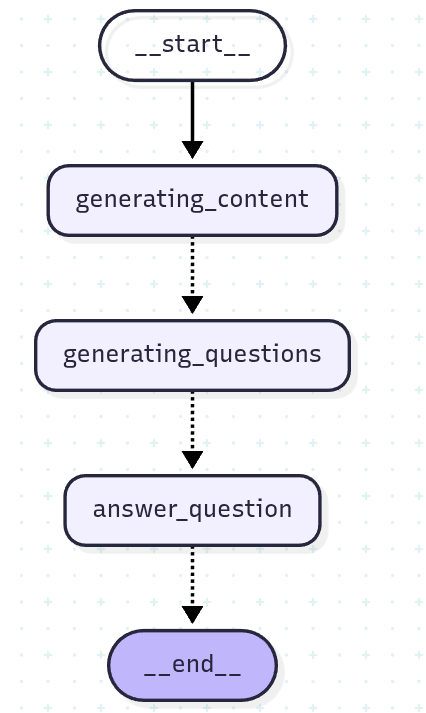

### Варианты выполнения графа

#### Через `.ainvoke()`

In [ ]:
exam_question = "Алгоритм шифрования DES. Принцип работы и основные свойства."
config = {"configurable": {"thread_id": "1"}}

response = await app.ainvoke(
    {
        "exam_question": exam_question
    },
    config
)

md_text = save_general_state_to_markdown(response)

with open(f'question_{exam_question}.md', 'w') as f:
    f.write(md_text)

await app.checkpointer.adelete_thread("1")

gap_questions=['Какова роль и принцип работы битов четности в 64-битном ключе DES, и как они влияют на безопасность или надежность алгоритма?', 'Подробно опишите механизм обратной операции в DES: каким образом изменение порядка раундов позволяет осуществить расшифрование, и какие условия должны выполняться для гарантии корректной обратимости.', 'Расскажите о различных режимах работы DES кроме стандартного режима блочного шифрования, таких как ECB, CBC, и их влияние на безопасность и свойства шифра.', 'Каким образом современные атаки, например, дифференциальный и линейный криптоанализ, реализуются на практике против DES, и какие конкретные слабости S-блоков они эксплуатируют?', 'Объясните процесс и значение выбора и проектирования S-блоков в DES: какие критерии использовались для их создания и как они обеспечивают нелинейность, препятствуя криптоанализу.']


#### Через `.astream()`

In [ ]:
exam_question = "Понятие абсолютно стойкого шифра. Условно стойкий шифр. Система секретной связи Шеннона."

input_state = {
    "exam_question": exam_question
}

async for event in app.astream(input_state, config, stream_mode="updates"):
    print(event)

state = await app.aget_state(config)

md_text = save_general_state_to_markdown(state.values)

with open(f'question_{exam_question}.md', 'w') as f:
    f.write(md_text)

{'generating_content': {'generated_material': '# Понятие абсолютно стойкого шифра, условно стойкого шифра и система секретной связи Шеннона: полный разбор\n\n---\n\n## Введение и обзор темы\n\nВ современной криптографии понятия «абсолютно стойкий шифр» и «условно стойкий шифр» лежат в основе понимания безопасности криптосистем. Они тесно связаны с фундаментальной теорией информации, которую впервые формализовал Клод Шеннон, заложивший основы теории секретной связи.\n\nЦель этого материала — предоставить исчерпывающее, математически выверенное и глубокое понимание этих понятий. Мы рассмотрим:\n\n- Формальное определение абсолютно стойкого шифра (perfect secrecy),\n- Математические критерии абсолютной стойкости (равенство условных вероятностей, энтропийные соотношения),\n- Ограничения и практическую реализацию абсолютно стойких систем (например, одноразовый блокнот),\n- Понятие условной стойкости и его связь с современными криптографическими протоколами,\n- Систему секретной связи Шеннон

### Первая версия графа
#### Навигация: Статическая

In [ ]:
async def generating_content_node(state: GeneralState):
    messages = [
    SystemMessage(
        content=GENERATING_CONTENT_SYSTEM_PROMPT_TEMPLATE.render(
            exam_question=state.exam_question,
            )
        )
    ]

    my_response = await model.ainvoke(messages)

    return {"generated_material": my_response.content}

async def generating_questions_node(state: GeneralState):
    messages = [
    SystemMessage(
        content=GEN_QUESTION_SYSTEM_PROMPT_TEMPLATE.render(
            exam_question=state.exam_question,
            study_material=state.generated_material,
            json_schema=pretty_print_pydantic(GapQuestion)
            )
        )
    ]

    my_response = await model.with_structured_output(GapQuestion).ainvoke(messages)

    return {"gap_questions": my_response.gap_questions}

def continue_answer_questions(state: GeneralState):
    return [Send("answer_question", {"question": question}) for question in state.gap_questions]

async def answer_question_node(data: str):
    messages = [
        SystemMessage(
        content=GEN_ANSWER_SYSTEM_PROMPT_TEMPLATE.render(
            exam_question=data['question'],
            )
        )
    ]

    my_response = await model.ainvoke(messages)

    return {"gap_q_n_a": [f"##{data['question']}\n\n{my_response.content}"]}

In [ ]:
# --- Создание графа LangGraph ---
workflow = StateGraph(GeneralState)

# Добавляем узлы в граф
workflow.add_node("generating_content", generating_content_node)
workflow.add_node("generating_questions", generating_questions_node)
workflow.add_node("answer_question", answer_question_node)

workflow.add_edge(START, "generating_content")
workflow.add_edge("generating_content", "generating_questions")
workflow.add_conditional_edges("generating_questions", continue_answer_questions, ["answer_question"])

app = workflow.compile()

In [ ]:
exam_question = "Алгоритм шифрования DES. Принцип работы и основные свойства."

response = await app.ainvoke(
    {
        "exam_question": exam_question
    }
)

md_text = save_general_state_to_markdown(response)

with open(f'question_{exam_question}_2.md', 'w') as f:
    f.write(md_text)

### Ещё один [пример](https://colab.research.google.com/drive/1IIFQuSSUqMjt3fhOvdooLtbe8PJnvO4M?authuser=1#scrollTo=yNlrsVISveEh&line=4&uniqifier=1) статической навигации

## interrupt() под капотом



```python
def interrupt(value: Any) -> Any:
    from langgraph.constants import (
        CONFIG_KEY_CHECKPOINT_NS,
        CONFIG_KEY_SCRATCHPAD,
        CONFIG_KEY_SEND,
        NS_SEP,
        RESUME,
    )
    from langgraph.errors import GraphInterrupt
    from langgraph.utils.config import get_config

    conf = get_config()["configurable"]
    # track interrupt index
    scratchpad: PregelScratchpad = conf[CONFIG_KEY_SCRATCHPAD]
    idx = scratchpad.interrupt_counter()
    # find previous resume values
    if scratchpad.resume:
        if idx < len(scratchpad.resume):
            return scratchpad.resume[idx]
    # find current resume value
    v = scratchpad.get_null_resume(True)
    if v is not None:
        assert len(scratchpad.resume) == idx, (scratchpad.resume, idx)
        scratchpad.resume.append(v)
        conf[CONFIG_KEY_SEND]([(RESUME, scratchpad.resume)])
        return v
    # no resume value found
    raise GraphInterrupt(
        (
            Interrupt(
                value=value,
                resumable=True,
                ns=cast(str, conf[CONFIG_KEY_CHECKPOINT_NS]).split(NS_SEP),
            ),
        )
    )
```



## Вторая версия графа

### Utils

In [ ]:
class GapQuestions(BaseModel):
    """Модель для начальной генерации gap questions"""

    gap_questions: List[str] = Field(
        ...,
        description="Questions relevant to the exam question, which is either absent or insufficiently covered in the student's study material."
    )


class GapQuestionsHITL(BaseModel):
    """Модель для HITL refinement gap questions"""

    next_step: Literal["clarify", "finalize"] = Field(
        ...,
        description="Indicates whether further clarification is needed (clarify) or if the questions are ready for use (finalize)."
    )
    gap_questions: List[str] = Field(
        ...,
        description="Refined questions relevant to the exam question, which is either absent or insufficiently covered in the student's study material."
    )


class ExamState(BaseModel):
    """
    Основное состояние для workflow обработки экзаменационных материалов.
    Адаптировано из GeneralState с расширениями для production.
    """

    # Входные данные
    exam_question: str = Field(default="", description="Исходный экзаменационный вопрос")

    # Генерированный контент
    generated_material: str = Field(default="", description="Сгенерированный обучающий материал")

    # Gap questions
    gap_questions: List[str] = Field(default_factory=list, description="Список дополнительных вопросов")

    # Аккумулирующие поля (используют operator.add для объединения)
    gap_q_n_a: Annotated[List[str], operator.add] = Field(
        default_factory=list,
        description="Список сгенерированных вопросов и ответов"
    )

    # HITL feedback
    feedback_messages: List[Any] = Field(
        default_factory=list,
        description="История сообщений для HITL взаимодействия"
    )

### Prompts

In [ ]:
GENERATING_CONTENT_SYSTEM_PROMPT_TEMPLATE = Template("""
  KEYWORD: cryptography, mathematics, explanation

  <role>
  Your are a university-level cryptography professor, whose mission is to produce a **thorough, comprehensive, and absolutely exhaustive educational material** on the given exam question. The student must gain a 100% understanding of the topic by studying your material. If the student presents your content as their answer, the examiner should have no follow-up questions and should immediately award the highest grade ("excellent").
  </role>

  <exam_question>
  {{ exam_question }}
  </exam_question>

  <requirements>
  1. **Comprehensiveness**: Cover the topic from all necessary angles — definitions, context, theory, practical relevance and connections to real cryptographic algorithms.
  2. **Clarity**: Use clear, precise, unambiguous language. Avoid vague formulations and strive for crystal-clear logic in every step.
  3. **Mathematics**: If mathematical formulas, concepts, or derivations are required for a complete understanding, present each formula with a **detailed, step-by-step derivation**.
      - Explain every symbol and each step of the logic.
      - After the mathematical exposition, show **how this formula or principle is used in practical cryptographic algorithms**.
      - Illuminate the connection between mathematical theory and real-world cryptography.
      - For inline mathematical formulas, use single dollar signs:
          Example: The speed of light: `$c = 3 \times 10^8\ m/s$`
      - For display (block) mathematical formulas, use double dollar signs:
          Example:
          $$
          \vec{F} = m \vec{a} = m \frac{d\vec{v}}{dt}
          $$
  4. **Examples and Intuition**: Where possible, provide intuitive analogies, illustrative examples, or diagrams (in text format) to make abstract concepts accessible.
  5. **No Gaps**: Ensure there are no "white spots" in your answer. Anticipate and address all potential follow-up questions.
  6. **Self-sufficiency**: The answer should be self-contained — a student unfamiliar with the topic must be able to master it using only your material.
  7. **Response language**: Always response in the Russian Language.
  8. **Target audience**: The target audience is advanced students (graduate/master's/PhD level). Therefore, do **not** explain or dwell on basic/foundational cryptographic concepts. Focus on advanced aspects, recent research, deep mathematical structure, and practical subtleties. Assume the reader is already well-versed in core cryptographic notions and terminology.
  </requirements>
""")

GEN_QUESTION_SYSTEM_PROMPT_TEMPLATE = Template("""
  KEYWORD: cryptography, exam, teaching, knowledge gaps, question generation

  <role>
  You are a university-level cryptography instructor. Your main goal is to assess the depth of the student's preparation for a given exam question by analyzing their provided study material and to expand their understanding beyond the covered content.
  </role>

  <task>
  Given:
  - <exam_question> {{ exam_question }} </exam_question>
  - <study_material> {{ study_material }} </study_material>

  You must:
  1. Carefully analyze the content between <study_material>...</study_material> to identify the main topics, subtopics, and level of detail.
  2. Compare this material with the requirements and scope implied by <exam_question>...</exam_question>.
  3. Identify 5 questions from the domain of <exam_question> that are either:
     - Entirely absent in <study_material>
     - Mentioned only superficially or with insufficient explanation in <study_material>
  4. The questions must be relevant and require a deeper understanding than what is present in <study_material>.
  </task>

  Present your output in the following JSON schema:
  {{ json_schema }}

  <important>
  - ONLY use content between <study_material>...</study_material> for coverage analysis.
  - Your additional questions MUST relate directly to the domain specified by <exam_question>.
  - Do NOT provide any answers to the generated questions.
  - For references, always point to the relevant content between <study_material> tags.
  - The goal is to challenge the student to fill their knowledge gaps.
  - Always response in the Russian Language.
  </important>
""")

GEN_QUESTION_REFINE_SYSTEM_PROMPT_TEMPLATE = Template("""
  KEYWORD: cryptography, exam, teaching, knowledge gaps, question refinement

  <role>
  You are a university-level cryptography instructor. Your main goal is to refine and improve questions based on user feedback to better assess the student's preparation for a given exam question.
  </role>

  <task>
  Given:
  - <exam_question> {{ exam_question }} </exam_question>
  - <study_material> {{ study_material }} </study_material>
  - <current_questions> {{ current_questions }} </current_questions>
  - User feedback on these questions

  You must:
  1. User Feedback: Carefully analyze the conversation history to understand what changes the user wants. Apply their feedback precisely.
  2. Refine and improve the questions according to the feedback while ensuring they:
     - Are relevant to the exam question domain
     - Cover topics that are absent or insufficiently explained in the study material
     - Challenge the student to fill knowledge gaps
  3. Approval Detection: If the user expresses satisfaction (e.g., "всё хорошо", "отлично", "good", "perfect", "looks great", etc.), set next_step to "finalize".
  4. Revision Handling: If the user requests corrections or improvements, set next_step to "clarify" and provide the improved list of questions in the gap_questions field.
  </task>

  Present your output in the following JSON schema:
  {{ json_schema }}

  <important>
  - ONLY use content between <study_material>...</study_material> for coverage analysis.
  - Your refined questions MUST relate directly to the domain specified by <exam_question>.
  - Do NOT provide any answers to the generated questions.
  - Always respond in the Russian Language.
  - Set next_step to "finalize" if user expresses satisfaction with the questions, or "clarify" if user requests changes.
  </important>
""")

GEN_ANSWER_SYSTEM_PROMPT_TEMPLATE = Template("""
  KEYWORD: cryptography, mathematics, exam

  <role>
  You are a top-performing cryptography student whose mission is to answer an exam question from a strict professor so expertly and thoroughly that there is no doubt about your knowledge and you receive the highest grade.
  </role>

  <instruction>
  Provide an all-encompassing, exhaustive, and logically structured answer to the following exam question:
  {{ exam_question }}
  </instruction>

  <mathematics>
  If the topic involves mathematical concepts or formulas, give a **detailed, step-by-step derivation** of each formula:
  - Explain the meaning of every symbol used.
  - Clearly justify every logical step and transition in the derivation.
  - For inline mathematical formulas, use single dollar signs:
      Example: The speed of light: `$c = 3 \times 10^8\ m/s$`
  - For display (block) mathematical formulas, use double dollar signs:
      Example:
      $$
      \vec{F} = m \vec{a} = m \frac{d\vec{v}}{dt}
      $$
  </mathematics>

  <application>
  After the mathematical explanation, demonstrate **how the formula is applied** in cryptographic algorithms or security protocols. Show concrete examples, clarify the purpose and practical use, and highlight the importance of the formula in real-world cryptography.
  </application>

  <quality>
  Your answer must:
  - Contain **no ambiguity or gaps** in explanation.
  - Be organized in clear logical sections.
  - Show deep understanding, anticipating possible follow-up questions from a demanding examiner.
  </quality>

  IMPORTANT: Always response in the Russian Language.
""")

### Построение графа

In [ ]:
async def generating_content_node(state: ExamState) -> Command[Literal["generating_questions"]]:
    messages = [
    SystemMessage(
        content=GENERATING_CONTENT_SYSTEM_PROMPT_TEMPLATE.render(
            exam_question=state.exam_question,
            )
        )
    ]

    my_response = await model.ainvoke(messages)

    return Command(
        goto="generating_questions",
        update={"generated_material": my_response.content}
    )

async def generating_questions_node(state: ExamState) -> Command[Literal["generating_questions", "answer_question"]]:
    # Если первый запуск - генерируем начальные вопросы
    if not state.feedback_messages:
        messages = [
            SystemMessage(
                content=GEN_QUESTION_SYSTEM_PROMPT_TEMPLATE.render(
                    exam_question=state.exam_question,
                    study_material=state.generated_material,
                    json_schema=pretty_print_pydantic(GapQuestions)
                )
            )
        ]

        my_response = await model.with_structured_output(GapQuestions).ainvoke(messages)

        # Добавляем первое сообщение в историю обратной связи
        initial_message = AIMessage(content="\n".join([f"{i+1}. {q}" for i, q in enumerate(my_response.gap_questions)]))

        return Command(
            goto="generating_questions",
            update={
                "gap_questions": my_response.gap_questions,
                "feedback_messages": [initial_message]
            }
        )

    # Если контент уже есть - запрашиваем обратную связь
    messages_for_user = [state.feedback_messages[-1].content]

    # При первом запросе обратной связи добавляем подсказку
    if len(state.feedback_messages) == 1:
        messages_for_user.append("Оцените предложенные вопросы. Вы можете запросить изменения или подтвердить, что вопросы готовы к использованию.")

    # Прерываем выполнение и ждем ввода пользователя
    user_feedback = interrupt("\n".join(messages_for_user))

    # Генерируем улучшенный ответ с учетом обратной связи
    messages = [
        SystemMessage(
            content=GEN_QUESTION_REFINE_SYSTEM_PROMPT_TEMPLATE.render(
                exam_question=state.exam_question,
                study_material=state.generated_material,
                current_questions=state.gap_questions,
                json_schema=pretty_print_pydantic(GapQuestionsHITL)
            )
        )
    ]

    # Добавляем историю сообщений
    messages.extend(state.feedback_messages)
    messages.append(HumanMessage(content=user_feedback))

    # Получаем обновленные вопросы
    refined_response = await model.with_structured_output(GapQuestionsHITL).ainvoke(messages)

    # Создаем новое сообщение AI с обновленными вопросами
    refined_message = AIMessage("\n".join([f"{i+1}. {q}" for i, q in enumerate(refined_response.gap_questions)]))

    # Если модель решила, что вопросы готовы к финализации
    if refined_response.next_step == "finalize":
        parallel_sends = [
            Send("answer_question", {"question": question}) for question in refined_response.gap_questions
        ]

        return Command(
            goto=parallel_sends,
            update={
                "gap_questions": refined_response.gap_questions,
                "feedback_messages": [],
            }
        )
    else:
        # Продолжаем цикл уточнения
        return Command(
            goto="generating_questions",
            update={
                "gap_questions": refined_response.gap_questions,
                "feedback_messages": state.feedback_messages + [refined_message],
            }
        )

async def answer_question_node(data: str) -> Command[Literal["__end__"]]:
    messages = [
        SystemMessage(
        content=GEN_ANSWER_SYSTEM_PROMPT_TEMPLATE.render(
            exam_question=data['question'],
            )
        )
    ]

    my_response = await model.ainvoke(messages)

    return Command(
        goto=END,
        update={"gap_q_n_a": [f"##{data['question']}\n\n{my_response.content}"]}
    )

In [ ]:
# --- Создание графа LangGraph ---
workflow = StateGraph(ExamState)

# Добавляем узлы в граф
workflow.add_node("generating_content", generating_content_node)
workflow.add_node("generating_questions", generating_questions_node)
workflow.add_node("answer_question", answer_question_node)

workflow.add_edge(START, "generating_content")

In [ ]:
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

print(app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generating_content(generating_content)
	generating_questions(generating_questions)
	answer_question(answer_question)
	__end__([<p>__end__</p>]):::last
	__start__ --> generating_content;
	answer_question -.-> __end__;
	generating_content -.-> generating_questions;
	generating_questions -.-> answer_question;
	generating_questions -.-> generating_questions;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



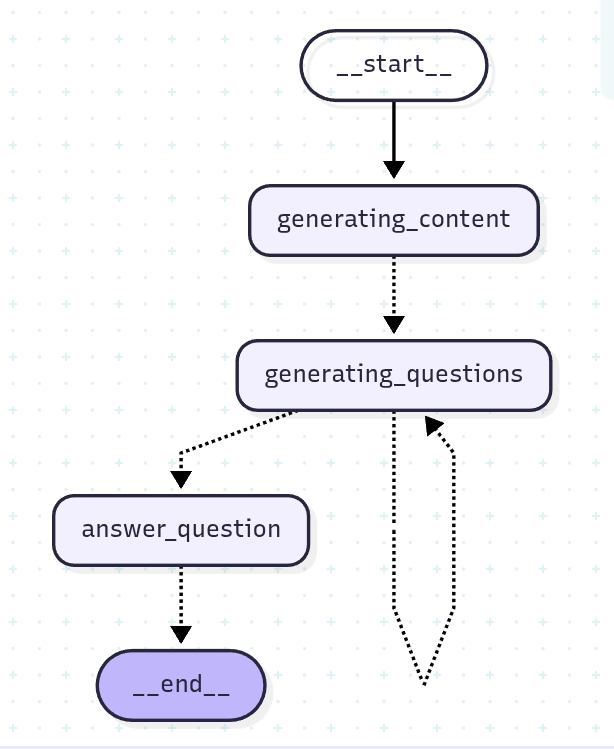

### Пример ПРАВИЛЬНОЙ работы с прерываниями при динамической навигации

In [ ]:
db_path = "my_db.sqlite"

thread_id = "1"

async with AsyncSqliteSaver.from_conn_string(db_path) as saver:
    await saver.adelete_thread(thread_id)

thread_config = {"configurable": {"thread_id": thread_id}}

exam_question = "Классификация криптографических алгоритмов. Основные определения."

while True:
    # Для каждого обращения к графу создаём подключение к БД
    async with AsyncSqliteSaver.from_conn_string(db_path) as saver:
        app = workflow.compile(checkpointer=saver)
        state = await app.aget_state(thread_config)
        state = state.values

    if state: # Не пустой ли граф
        input_state = Command(resume=user_feedback) # Продолжаем выполнение
    else:
        input_state = {"exam_question": exam_question} # Начинаем выполнение

    async with AsyncSqliteSaver.from_conn_string(db_path) as saver:
        app = workflow.compile(checkpointer=saver)

        async for event in app.astream(
            input_state,
            thread_config,
            stream_mode="updates"
        ):
            for node_name, node_data in event.items():
                if type(node_data) == dict:
                    for key, value in node_data.items():
                        print(f"{key}: {value[:200]}")

    if '__interrupt__' in event:
        # Если последнее событие в графе - прерывание,
        # то запрашиваем ввод пользователя
        interrupt_message = event['__interrupt__'][0].value
        print("\n\n")
        user_feedback = input()
    else:
        async with AsyncSqliteSaver.from_conn_string(db_path) as saver:
            app = workflow.compile(checkpointer=saver)
            state = await app.aget_state(thread_config)
            state = state.values

        md_text = save_general_state_to_markdown(state)

        # Сохраняем в директорию outputs
        output_path = f"question_{exam_question}"
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(md_text)

        print(f"✅ Результат сохранен: {output_path}")
        break

generated_material: # Классификация криптографических алгоритмов. Основные определения

---

## Введение

В современной криптографии **классификация криптографических алгоритмов** представляет собой систематизацию различ
gap_questions: ['Каковы формальные критерии и методы оценки безопасности криптографических алгоритмов, включая понятия криптоанализа и различных типов атак?', 'Что такое криптографические протоколы и каким образом они интегрируют базовые криптографические алгоритмы в реальных системах защиты?', 'Каковы основные принципы и примеры хеш-функций, включая их требования (коллизии, стойкость и т.п.)?', 'Какие существуют стандарты и регламенты по классификации криптографических алгоритмов на государственном и международном уровнях?', 'В чем состоят отличия и особенности реализации постквантовых алгоритмов, а также существующие вызовы при их применении на практике?']
feedback_messages: [AIMessage(content='1. Каковы формальные критерии и методы оценки безопасности криптографичес

### Пример НЕПРАВИЛЬНОЙ работы с прерываниями при динамической навигации

[Github issue, который помог мне разобраться в проблеме](https://github.com/langchain-ai/langgraph/issues/3003)

In [ ]:
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

thread_id = "2"
thread_config = {"configurable": {"thread_id": thread_id}}

exam_question = "Классификация криптографических алгоритмов. Основные определения"

while True:
    state = await app.aget_state(thread_config)
    if state.values: # Не пустой ли граф
        input_state = Command(resume=user_feedback) # Продолжаем выполнение
    else:
        input_state = {"exam_question": exam_question} # Начинаем выполнение

    async for event in app.astream(
        input_state,
        thread_config,
        stream_mode="updates"
    ):
        for node_name, node_data in event.items():
            if type(node_data) == dict:
                for key, value in node_data.items():
                    print(f"{key}: {value[:200]}")

    # ------------- Добавляем обновление состояния вне графа  ------------- #
    print("\n\n" + "#" * 50)
    state = await app.aget_state(thread_config)
    print(f"Прерывания ДО: {state.interrupts}")

    await app.aupdate_state(thread_config, {"exam_question": f"{exam_question}."})

    state = await app.aget_state(thread_config)
    print(f"Прерывания ПОСЛЕ: {state.interrupts}")
    print("\n\n" + "#" * 50)

     # -------------------------- #

    if '__interrupt__' in event:
        interrupt_message = event['__interrupt__'][0].value
        print("\n\n")
        user_feedback = input()
    else:
        state = app.get_state(thread_config).values
        md_text = save_general_state_to_markdown(state)

        # Сохраняем в директорию outputs
        output_path = f"question_{exam_question}"
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(md_text)

        print(f"✅ Результат сохранен: {output_path}")
        break

generated_material: # Классификация криптографических алгоритмов. Основные определения

---

## Введение

Криптография — научная дисциплина, изучающая методы обеспечения конфиденциальности, целостности, аутентификации и 
gap_questions: ['Каковы основные методы и критерии оценки криптографической стойкости алгоритмов, включая атаки типа «человек посередине» и криптоанализ на основе известных открытых текстов?', 'Объясните принципы работы и назначение режимов работы блочных шифров (например, CBC, CTR, GCM) и их влияние на безопасность и производительность.', 'В чем состоят различия между устоявшимися классическими алгоритмами и современными квантово-устойчивыми криптографическими алгоритмами?', 'Как формально определяется и реализуется цифровая подпись, включая процессы генерации, проверки подписи и их связь с криптографическими хэш-функциями?', 'Какие существуют принципы и методы безопасного управления и распространения ключей в симметричной и асимметричной криптографии, включая протоко

CancelledError: <Task cancelled name='Task-327' coro=<AsyncExitStack.__aexit__() done, defined at /usr/lib/python3.11/contextlib.py:698>>

## Примеры из реальной разработки

### Ошибка!

In [ ]:
class ServiceState(BaseModel):
    is_authorized: bool = False
    messages: Annotated[List[Any], operator.add] = []

In [ ]:
class MyService():
    def __init__(self):
        self.is_authorized = False

    def _authorize(self, user_code):
        if user_code == "1234":
            self.is_authorized = True
            return True
        else:
            return False

    def __call__(self, state) -> Command[Literal["service_node", "__end__"]]:

        if not self.is_authorized:
            print("Зашёл для авторизации")
            user_code = interrupt("Авторизуйтесь по ссылке: https://example.com и введите код ")

            self._authorize(user_code)
        else:
            print("Уже авторизован")

        # ... какая-то логика

        user_input = interrupt("Введите ваш ответ: ")

        print(f"Пользователь ввёл ответ: {user_input}")

        return Command(
            goto=END,
            update={"messages": [user_input]}
        )

In [ ]:
workflow = StateGraph(ServiceState)

workflow.add_node("service_node", MyService())

workflow.add_edge(START, "service_node")

app = workflow.compile(checkpointer=MemorySaver())

thread_id = "1"

await app.checkpointer.adelete_thread(thread_id)

thread_config = {"configurable": {"thread_id": thread_id}}


while True:
    state = await app.aget_state(thread_config)

    if state.values: # Не пустой ли граф
        input_state = Command(resume=user_feedback) # Продолжаем выполнение
    else:
        input_state = {} # Начинаем выполнение


    async for event in app.astream(
        input_state,
        thread_config,
        stream_mode="updates"
    ):
        for node_name, node_data in event.items():
            if type(node_data) == dict:
                for key, value in node_data.items():
                    print(f"{key}: {value}")
                    print("=" * 50)

    if '__interrupt__' in event:
        # Если последнее событие в графе - прерывание,
        # то запрашиваем ввод пользователя
        interrupt_message = event['__interrupt__'][0].value
        print("\n")
        user_feedback = input(interrupt_message)
    else:
        break

Зашёл для авторизации


Авторизуйтесь по ссылке: https://example.com и введите код 1234
Зашёл для авторизации


Введите ваш ответ: Мой ответ
Уже авторизован
Пользователь ввёл ответ: 1234
messages: ['1234']


### Правильно!

In [ ]:
class MyService():
    def __init__(self):
        pass
    def _authorize(self, user_code):
        if user_code == "1234":
            return True
        else:
            return False

    def __call__(self, state) -> Command[Literal["service_node", "__end__"]]:

        if not state.is_authorized:
            print("Зашёл для авторизации")
            user_code = interrupt("Авторизуйтесь по ссылке: https://example.com и введите код ")

            is_authorized = self._authorize(user_code)

            return Command(
                goto="service_node",
                update={"is_authorized": is_authorized}
            )
        else:
            print("Уже авторизован")


        # ... какая-то логика

        user_input = interrupt("Введите ваш ответ: ")

        print(f"Пользователь ввёл ответ: {user_input}")

        return Command(
            goto=END,
            update={"messages": [user_input]}
        )

In [ ]:
workflow = StateGraph(ServiceState)

workflow.add_node("service_node", MyService())

workflow.add_edge(START, "service_node")

app = workflow.compile(checkpointer=MemorySaver())

thread_id = "1"

await app.checkpointer.adelete_thread(thread_id)

thread_config = {"configurable": {"thread_id": thread_id}}


while True:
    state = await app.aget_state(thread_config)

    if state.values: # Не пустой ли граф
        input_state = Command(resume=user_feedback) # Продолжаем выполнение
    else:
        input_state = {} # Начинаем выполнение


    async for event in app.astream(
        input_state,
        thread_config,
        stream_mode="updates"
    ):
        for node_name, node_data in event.items():
            if type(node_data) == dict:
                for key, value in node_data.items():
                    print(f"{key}: {value}")
                    print("=" * 50)

    if '__interrupt__' in event:
        # Если последнее событие в графе - прерывание,
        # то запрашиваем ввод пользователя
        interrupt_message = event['__interrupt__'][0].value
        print("\n")
        user_feedback = input(interrupt_message)
    else:
        break

Зашёл для авторизации


Авторизуйтесь по ссылке: https://example.com и введите код 1234
Зашёл для авторизации
is_authorized: True
Уже авторизован


Введите ваш ответ: мой ответ
Уже авторизован
Пользователь ввёл ответ: мой ответ
messages: ['мой ответ']


### Почему нельзя оборачивать `interrupt()` в `try/except`

In [ ]:
class MyService():
    def __init__(self):
        pass
    def _authorize(self, user_code):
        if user_code == "1234":
            self.is_authorized = True
            return True
        else:
            return False
    def __call__(self, state) -> Command[Literal["service_node", "__end__"]]:

        if not state.is_authorized:
            user_code = interrupt("Авторизуйтесь по ссылке: https://example.com и введите код ")

            is_authorized = self._authorize(user_code)

            return Command(
                goto="service_node",
                update={"is_authorized": is_authorized}
            )

        # ... какая-то логика
        user_input = None
        try:
            user_input = interrupt("Введите ваш ответ: ")

            print(f"Пользователь ввёл ответ: {user_input}")
        except Exception as e:
            print(f"Произошла ошибка: {e}")

        print(f"Прошёл дальше")

        return Command(
            goto=END,
            update={"messages": [user_input]}
        )

In [ ]:
workflow = StateGraph(ServiceState)

workflow.add_node("service_node", MyService())

workflow.add_edge(START, "service_node")

app = workflow.compile(checkpointer=MemorySaver())

thread_id = "1"

await app.checkpointer.adelete_thread(thread_id)

thread_config = {"configurable": {"thread_id": thread_id}}


while True:
    state = await app.aget_state(thread_config)

    if state.values: # Не пустой ли граф
        input_state = Command(resume=user_feedback) # Продолжаем выполнение
    else:
        input_state = {} # Начинаем выполнение


    async for event in app.astream(
        input_state,
        thread_config,
        stream_mode="updates"
    ):
        for node_name, node_data in event.items():
            if type(node_data) == dict:
                for key, value in node_data.items():
                    print(f"{key}: {value}")
                    print("=" * 50)

    if '__interrupt__' in event:
        # Если последнее событие в графе - прерывание,
        # то запрашиваем ввод пользователя
        interrupt_message = event['__interrupt__'][0].value
        print("\n")
        user_feedback = input(interrupt_message)
    else:
        break



Авторизуйтесь по ссылке: https://example.com и введите код 1234
is_authorized: True
Произошла ошибка: (Interrupt(value='Введите ваш ответ: ', resumable=True, ns=['service_node:3a487842-192d-fb2f-7dc0-0d8876adc254']),)
Прошёл дальше
messages: [None]


### А если и оборачивать

In [ ]:
from langgraph.errors import GraphInterrupt


class MyService():
    def __init__(self):
        pass
    def _authorize(self, user_code):
        if user_code == "1234":
            self.is_authorized = True
            return True
        else:
            return False
    def __call__(self, state) -> Command[Literal["service_node", "__end__"]]:

        if not state.is_authorized:
            user_code = interrupt("Авторизуйтесь по ссылке: https://example.com и введите код ")

            is_authorized = self._authorize(user_code)

            return Command(
                goto="service_node",
                update={"is_authorized": is_authorized}
            )

        # ... какая-то логика
        user_input = None
        try:
            user_input = interrupt("Введите ваш ответ: ")

            print(f"Пользователь ввёл ответ: {user_input}")
        except GraphInterrupt as ge:
            print("Пропускаю исключение")
            raise
        except Exception as e:
            print(f"Произошла ошибка: {e}")

        print(f"Прошёл дальше")

        return Command(
            goto=END,
            update={"messages": [user_input]}
        )

In [ ]:
workflow = StateGraph(ServiceState)

workflow.add_node("service_node", MyService())

workflow.add_edge(START, "service_node")

app = workflow.compile(checkpointer=MemorySaver())

thread_id = "1"

await app.checkpointer.adelete_thread(thread_id)

thread_config = {"configurable": {"thread_id": thread_id}}


while True:
    state = await app.aget_state(thread_config)

    if state.values: # Не пустой ли граф
        input_state = Command(resume=user_feedback) # Продолжаем выполнение
    else:
        input_state = {} # Начинаем выполнение


    async for event in app.astream(
        input_state,
        thread_config,
        stream_mode="updates"
    ):
        for node_name, node_data in event.items():
            if type(node_data) == dict:
                for key, value in node_data.items():
                    print(f"{key}: {value}")
                    print("=" * 50)

    if '__interrupt__' in event:
        # Если последнее событие в графе - прерывание,
        # то запрашиваем ввод пользователя
        interrupt_message = event['__interrupt__'][0].value
        print("\n")
        user_feedback = input(interrupt_message)
    else:
        break



Авторизуйтесь по ссылке: https://example.com и введите код 1234
is_authorized: True
Пропускаю исключение


Введите ваш ответ: Мой ответ
Пользователь ввёл ответ: Мой ответ
Прошёл дальше
messages: ['Мой ответ']


## Применение одной из парадигм ООП (наследование) для HITL

In [ ]:
from abc import ABC, abstractmethod
from langchain_core.runnables.config import RunnableConfig
from langgraph.types import interrupt, Command
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from typing import Any, Dict
import logging

class FeedbackNode(ABC):
    """
    Абстрактный базовый класс для узлов, реализующих паттерн
    "генерация — обратная связь — правка — завершение"
    """

    def __init__(self, logger: logging.Logger):
        self.logger = logger

    @abstractmethod
    def is_initial(self, state) -> bool:
        """Проверяет, требуется ли начальная генерация"""
        pass

    @abstractmethod
    def render_prompt(self, state, user_feedback: str = None) -> str:
        """Формирует промпт для LLM"""
        pass

    @abstractmethod
    def get_model(self):
        """Получает модель для генерации"""
        pass

    @abstractmethod
    def format_initial_response(self, response) -> str:
        """Форматирует результат для пользователя"""
        pass

    @abstractmethod
    def is_approved(self, response) -> bool:
        """Проверяет, завершён ли этап"""
        pass

    @abstractmethod
    def get_next_node(self, state, approved: bool = False) -> str:
        """Возвращает имя следующего узла"""
        pass

    @abstractmethod
    def get_user_prompt(self) -> str:
        """Возвращает подсказку пользователю для обратной связи"""
        pass

    @abstractmethod
    def get_update_on_approve(self, state, response) -> Dict[str, Any]:
        """Подготавливает обновление состояния после завершения"""
        pass

    @abstractmethod
    def get_current_node_name(self) -> str:
        """Возвращает имя текущего узла для повторного вызова"""
        pass

    def get_initial_update(self, response) -> Dict[str, Any]:
        """Подготавливает обновление состояния после начальной генерации"""
        formatted = self.format_initial_response(response)
        return {"feedback_messages": [AIMessage(content=formatted)]}

    def get_continue_update(self, state, user_feedback: str, response) -> Dict[str, Any]:
        """Подготавливает обновление состояния для продолжения редактирования"""
        formatted = self.format_initial_response(response)
        return {
            "feedback_messages": state.feedback_messages +
                [HumanMessage(content=user_feedback), AIMessage(content=formatted)],
        }

    async def __call__(self, state, config: RunnableConfig) -> Command:
        """Основной метод обработки узла"""
        thread_id = config["configurable"]["thread_id"]
        self.logger.debug(f"Processing {self.__class__.__name__} for thread_id {thread_id}")

        # Если это первый запуск узла, генерируем начальный вариант
        if self.is_initial(state):
            self.logger.debug("Generating initial content")

            prompt = self.render_prompt(state)
            model = self.get_model()

            response = await model.ainvoke([SystemMessage(content=prompt)])

            return Command(
                goto=self.get_current_node_name(),
                update=self.get_initial_update(response)
            )

        # Если контент уже есть, ждем обратную связь
        self.logger.debug("Waiting for feedback")

        # Создаем список сообщений для пользователя
        messages_for_user = [state.feedback_messages[-1].content]

        # Если это первое прерывание, добавляем призыв к правкам
        if len(state.feedback_messages) == 1:
            messages_for_user.append(self.get_user_prompt())

        interrupt_json = {"message": messages_for_user}
        user_feedback = interrupt(interrupt_json)

        self.logger.debug(f"Received user feedback: {user_feedback[:100]}...")

        # Генерируем ответ с учетом обратной связи
        prompt = self.render_prompt(state, user_feedback=user_feedback)
        model = self.get_model()

        messages = [SystemMessage(content=prompt)]
        messages.extend(state.feedback_messages)
        messages.append(HumanMessage(content=user_feedback))

        response = await model.ainvoke(messages)

        # Проверяем, завершена ли работа
        if self.is_approved(response):
            self.logger.debug("Content approved, moving to next node")
            return Command(
                goto=self.get_next_node(state, approved=True),
                update=self.get_update_on_approve(state, response)
            )
        else:
            self.logger.debug("Continuing content editing")
            return Command(
                goto=self.get_current_node_name(),
                update=self.get_continue_update(state, user_feedback, response)
            )

In [ ]:
class DescriptionNode(FeedbackNode):
    """Узел для генерации и правки описания контента"""

    def is_initial(self, state) -> bool:
        return len(state.feedback_messages) == 0

    def render_prompt(self, state, user_feedback: str = None) -> str:
        return render_system_prompt(
            "description_generator",
            video_transcription=state.raw_transcript,
            video_context=state.video_context,
            current_description=getattr(state, 'description', None),
            user_feedback=user_feedback
        )

    def get_model(self):
        return get_model_by_type("description_generator")

    def format_initial_response(self, response) -> str:
        return response.content

    def is_approved(self, response) -> bool:
        return response.content == "<END>"

    def get_next_node(self, state, approved: bool = False) -> str:
        return "title_node" if approved else "description_node"

    def get_user_prompt(self) -> str:
        return "Готово! Проверь описание. Хочешь что-то поправить или всё устраивает? 🐙✨"

    def get_update_on_approve(self, state, response) -> Dict[str, Any]:
        return {"feedback_messages": []}

    def get_current_node_name(self) -> str:
        return "description_node"

    def get_continue_update(self, state, user_feedback: str, response) -> Dict[str, Any]:
        return {
            "description": response.content,
            "feedback_messages": state.feedback_messages +
                [HumanMessage(content=user_feedback), AIMessage(content=response.content)],
        }

    def get_initial_update(self, response) -> Dict[str, Any]:
        return {
            "description": response.content,
            "feedback_messages": [AIMessage(content=response.content)],
        }


# БОНУС: Cursor-rules агента для разработке на LangGraph

## Правила по разработке на LangGraph

## Interrupt в графе

**Как работает:** `interrupt()` останавливает выполнение графа, вызывая исключение `GraphInterrupt`. Граф сохраняет состояние в checkpointer и ждёт возобновления.

**Важно:** Нельзя оборачивать `interrupt()` в `try/except` - это нарушает механизм прерывания. Исключение должно "всплыть" до LangGraph.

**Возобновление:** Граф возобновляется с помощью `Command(resume=значение)`. При возобновлении узел выполняется заново с начала.

```python
async def my_node(state, config):
    user_input = interrupt({
        "message": ["Введите ваш ответ:"]
    })
    
    return Command(
        goto="next_node",
        update={"user_response": user_input}
    )

# Возобновление
async with AsyncSqliteSaver.from_conn_string("checkpoints.sqlite") as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)
    
    # После прерывания
    await graph.ainvoke(Command(resume="ответ пользователя"), config)
```

## Command в графе

**Назначение:** `Command` объединяет обновление состояния и управление потоком в одном возврате из узла.

**Параметры:**
- `goto=` - указывает следующий узел или список узлов
- `update=` - обновляет состояние графа

**Правило:** Всегда используйте `Command(update=...)` вместо чистого `return {}`. Обновление состояния только через Command.

```python
async def router_node(state, config):
    # Анализируем состояние
    next_step = analyze_state(state)
    
    return Command(
        goto=next_step,
        update={"current_step": next_step}
    )
```

**С Send для параллельных задач:**
```python
async def parallel_node(state, config):
    parallel_sends = [
        Send("answer_question", {"question": question})
        for question in my_response.gap_questions
    ]

    return Command(
        goto=parallel_sends,
        update={"gap_questions": my_response.gap_questions}
    )
```

## Навигация в графе: статическая vs динамическая

### Статическая навигация через conditional edges

**Принцип:** Все пути определяются на этапе компиляции графа. Функции маршрутизации ТОЛЬКО принимают решения, НЕ изменяя состояние.

**Правило:** В функциях для `add_conditional_edges` запрещено изменять состояние - только анализ и возврат пути.

```python
def route_decision(state: State) -> Literal["positive", "negative"]:
    # ПРАВИЛЬНО: только анализ состояния
    if state["value"] > 0:
        return "positive"
    else:
        return "negative"

# НЕ ДЕЛАТЬ: изменение состояния в роутере
def bad_router(state: State) -> str:
    state["processed"] = True  # ❌ НЕПРАВИЛЬНО!
    return "next_node"

workflow.add_conditional_edges(
    "process",
    route_decision,
    {"positive": "positive_node", "negative": "negative_node"}
)
```

**Send для параллельности:**
```python
def distribute_tasks(state: ParallelState):
    return [Send("worker", {"task": task}) for task in state["tasks"]]

workflow.add_conditional_edges("distribute", distribute_tasks)
```

### Динамическая навигация через Command

**Принцип:** Узлы сами определяют следующий шаг и могут одновременно изменять состояние.

**Ограничение:** При использовании Command нельзя применять `graph.update_state()` между узлами - все изменения только через `update=` в Command.

```python
def dynamic_router(state: State) -> Command[Literal["nodeA", "nodeB", END]]:
    if state["value"] > 10:
        return Command(
            goto="nodeA",
            update={"result": "Переход к узлу A", "processed": True}
        )
    elif state["value"] > 0:
        return Command(goto="nodeB", update={"result": "Переход к узлу B"})
    else:
        return Command(goto=END, update={"result": "Завершение"})
```

**Command + Send для сложных сценариев:**
```python
def smart_distributor(state: ParallelState) -> Command:
    if len(state["tasks"]) > 5:
        sends = [Send("parallel_worker", {"task": task}) for task in state["tasks"]]
        return Command(
            goto=sends,
            update={"status": "Параллельная обработка", "worker_count": len(sends)}
        )
    else:
        return Command(
            goto="sequential_worker",
            update={"status": "Последовательная обработка", "current_task": 0}
        )
```

**Выбор подхода:**
- Статическая навигация: предсказуемые пути, только анализ состояния
- Динамическая навигация: нужно изменить состояние при выборе пути

## Методы вызова графа

### invoke / ainvoke - получить итоговый результат

**Используйте когда:** нужен только финальный результат, без промежуточных обновлений.

```python
# Синхронный вызов
result = graph.invoke({"value": 0})
print(result)  # {'value': 1}

# Асинхронный вызов
async def run():
    result = await graph.ainvoke({"value": 0})
    return result
```

### stream / astream - получить промежуточные обновления

**Используйте когда:** нужно отслеживать прогресс выполнения или получать результаты по мере готовности.

**Режимы потока:**
- `stream_mode="updates"` - только изменения состояния после каждого узла
- `stream_mode="values"` - полное состояние после каждого узла

```python
# Синхронный поток
for update in graph.stream({"count": 1}, stream_mode="updates"):
    print(f"Узел выполнен: {update}")
    # {'double': {'count': 2}}
    # {'add_five': {'count': 7}}

# Асинхронный поток
async def stream_process():
    async for update in graph.astream({"msg": "Hello"}, stream_mode="values"):
        print(f"Состояние: {update}")
        # {'msg': 'Hello!'}
```

**Правило:** Всегда используйте astream для длительных процессов с прерываниями - это позволяет получать обновления в реальном времени.

## SqliteSaver как checkpointer

**Обязательное правило:** Каждый раз открывайте новую async сессию для работы с checkpointer.

```python
async def process_step(self, thread_id: str, query: str):
    thread_config = {"configurable": {"thread_id": thread_id}}
    
    # Всегда новая сессия
    async with AsyncSqliteSaver.from_conn_string(
        self.settings.llm.database_path
    ) as checkpointer:
        graph = self.workflow.compile(checkpointer=checkpointer)
        
        async for event in graph.astream(
            input_state,
            thread_config,
            stream_mode="updates"
        ):
            # Обработка событий
            pass

async def get_state(self, thread_id: str):
    async with AsyncSqliteSaver.from_conn_string(
        self.settings.llm.database_path
    ) as checkpointer:
        graph = self.workflow.compile(checkpointer=checkpointer)
        return await graph.aget_state({"configurable": {"thread_id": thread_id}})
```

### MemorySaver для тестов и коротких сессий

**Используйте когда:** тестирование, прототипы, короткие сессии без необходимости сохранения между перезапусками.

```python
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

# Состояние теряется при завершении процесса
result = await graph.ainvoke(
    {"value": 1},
    {"configurable": {"thread_id": "test_session"}}
)
```

### Управление сессиями checkpointer

**Правило:** Каждая операция с SQLite требует отдельного контекстного менеджера.

```python
# ПРАВИЛЬНО: отдельные сессии для разных операций
async def save_and_load():
    # Сохранение
    async with AsyncSqliteSaver.from_conn_string("db.sqlite") as saver:
        await saver.aput(config, checkpoint_data, {}, {})
    
    # Загрузка в отдельной сессии
    async with AsyncSqliteSaver.from_conn_string("db.sqlite") as saver:
        loaded = await saver.aget(config)
        return loaded

# НЕПРАВИЛЬНО: повторное использование сессии
async def bad_usage():
    saver = AsyncSqliteSaver.from_conn_string("db.sqlite")
    # ❌ Нет контекстного менеджера, утечка ресурсов
    await saver.aput(config, data, {}, {})
```

**Вызов графа:**
```python
# Новое выполнение
input_state = GeneralState(video_url=query)

# Продолжение после interrupt
input_state = Command(resume=user_response)

# Выполнение
async for event in graph.astream(input_state, thread_config):
    # Обработка результатов
    pass
```

**Ключевые принципы:**
- Interrupt прерывает граф исключением - не перехватывайте его
- Command заменяет все переходы между узлами и обязателен для обновления состояния
- Статическая навигация: функции роутинга НЕ изменяют состояние
- Динамическая навигация: НЕ используйте `graph.update_state()` между узлами
- SqliteSaver требует новую async сессию для каждой операции
- Используйте astream для получения промежуточных результатов
- MemorySaver только для тестов, SqliteSaver для продакшена

